# RAGDoll UMBRELA Bedrock judgment dashboard

Visualizes `evaluation-results/aus-agent/umbrela-bedrock/judgments.jsonl`. The loader is safe to rerun while judgment generation is still in progress.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 160)

cwd = Path.cwd().resolve()
repo = next((p for p in [cwd, *cwd.parents] if (p / 'evaluation-results').is_dir()), None)
assert repo is not None, 'Could not locate repository root'
results_dir = repo / 'evaluation-results' / 'aus-agent' / 'umbrela-bedrock'
judgments_path = results_dir / 'judgments.jsonl'
requests_path = results_dir / 'requests.jsonl'
assert judgments_path.exists(), f'Missing {judgments_path}'

def read_jsonl_tolerant(path):
    rows, malformed = [], []
    with path.open(encoding='utf-8') as stream:
        for line_number, line in enumerate(stream, 1):
            if not line.strip():
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                malformed.append((line_number, str(exc)))
    return pd.DataFrame(rows), malformed

df, malformed_lines = read_jsonl_tolerant(judgments_path)
print(f'Loaded {len(df):,} rows from {judgments_path.relative_to(repo)}')
print(f'Last modified: {pd.Timestamp(judgments_path.stat().st_mtime, unit="s")}')

Loaded 2,362 rows from evaluation-results\aus-agent\umbrela-bedrock\judgments.jsonl
Last modified: 2026-07-18 11:39:37.915245295


## Data-quality and run health

In [2]:
status = df.get('status', pd.Series(dtype='object')).value_counts(dropna=False)
duplicate_rows = int(df.duplicated('task_id', keep=False).sum()) if 'task_id' in df else 0
invalid_scores = int((~pd.to_numeric(df.get('judgment'), errors='coerce').isin([0, 1, 2, 3])).sum())
health = pd.Series({
    'Rows loaded': len(df),
    'Unique tasks': df.task_id.nunique() if 'task_id' in df else 0,
    'Completed': int(status.get('completed', 0)),
    'Failed': int(status.get('failed', 0)),
    'Rows belonging to duplicate task IDs': duplicate_rows,
    'Invalid/missing judgments': invalid_scores,
    'Malformed JSONL lines': len(malformed_lines),
})
display(health.to_frame('value'))
if malformed_lines:
    display(pd.DataFrame(malformed_lines, columns=['line', 'error']))
if 'error' in df:
    errors = df.loc[df.status.ne('completed'), 'error'].fillna('(no error text)').value_counts()
    if len(errors): display(errors.rename_axis('error').to_frame('count'))

,value
Rows loaded,2362
Unique tasks,2362
Completed,2353
Failed,9
Rows belonging to duplicate task IDs,0
Invalid/missing judgments,9
Malformed JSONL lines,0


,count
error,
(no error text),7
local agent completed without assistant text,2


## Score distribution

,count,rate
judgment,,
0,352,0.149596
1,1251,0.531662
2,567,0.240969
3,183,0.077773


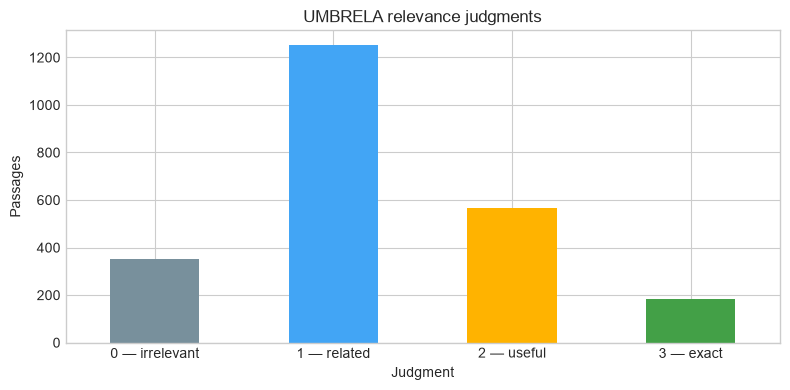

In [3]:
valid = df[df.status.eq('completed')].copy()
valid['judgment'] = pd.to_numeric(valid.judgment, errors='coerce')
valid = valid[valid.judgment.isin([0, 1, 2, 3])]
score_counts = valid.judgment.value_counts().reindex(range(4), fill_value=0)
score_rates = (score_counts / score_counts.sum()).rename('rate')
display(pd.concat([score_counts.rename('count'), score_rates], axis=1))
ax = score_counts.plot.bar(figsize=(8, 4), color=['#78909c', '#42a5f5', '#ffb300', '#43a047'])
ax.set(title='UMBRELA relevance judgments', xlabel='Judgment', ylabel='Passages')
ax.set_xticklabels(['0 — irrelevant', '1 — related', '2 — useful', '3 — exact'], rotation=0)
plt.tight_layout(); plt.show()

## Results by run split

,score_0,score_1,score_2,score_3,total,mean_score
run_id,,,,,,
aus-agent-test-v2,127,546,288,87,1048,1.319656
aus-agent-test-full,102,365,170,43,680,1.226471
aus-agent-dev-full,97,262,73,19,451,1.031042
aus-agent-creative-check,25,71,29,8,133,1.150376
viewer-20260717T020657,0,1,1,5,7,2.571429
aus-agent-math-check,0,1,2,3,6,2.333333
aus-agent-discovery-check,0,1,1,4,6,2.500000
viewer-20260717T020901,0,4,0,2,6,1.666667
aus-agent-protocol-check-v5,1,0,1,3,5,2.200000


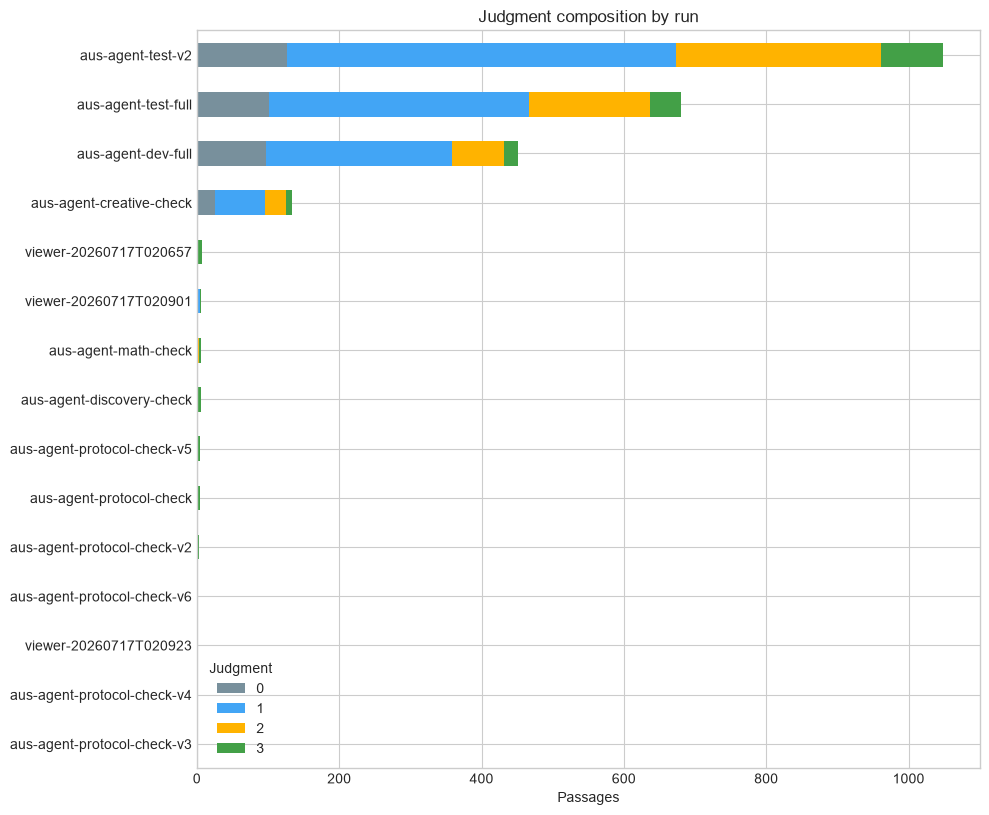

In [4]:
valid['run_id'] = valid.qid.str.split('::', n=1).str[0]
by_run = (valid.groupby(['run_id', 'judgment']).size().unstack(fill_value=0)
          .reindex(columns=range(4), fill_value=0))
by_run.columns = [f'score_{int(c)}' for c in by_run.columns]
by_run['total'] = by_run.sum(axis=1)
by_run['mean_score'] = valid.groupby('run_id').judgment.mean()
display(by_run.sort_values('total', ascending=False))
plot_data = by_run.loc[by_run.total.sort_values().index, [f'score_{i}' for i in range(4)]]
ax = plot_data.plot.barh(stacked=True, figsize=(10, max(4, len(plot_data) * 0.55)),
                         color=['#78909c', '#42a5f5', '#ffb300', '#43a047'])
ax.set(title='Judgment composition by run', xlabel='Passages', ylabel='')
ax.legend(['0', '1', '2', '3'], title='Judgment')
plt.tight_layout(); plt.show()

## Query-level relevance profile

,run_id,qid,passages,mean_score,relevant_at_2,exact,query,relevant_at_2_rate
43,aus-agent-protocol-check-v3,aus-agent-protocol-check-v3::adhoc,1,3.000000,1,1,Who's the president of the United States?,1.0
44,aus-agent-protocol-check-v4,aus-agent-protocol-check-v4::adhoc,1,3.000000,1,1,Who's the president of the United States?,1.0
46,aus-agent-protocol-check-v6,aus-agent-protocol-check-v6::adhoc,1,3.000000,1,1,Who's the president of the United States?,1.0
175,viewer-20260717T020923,viewer-20260717T020923::adhoc,1,3.000000,1,1,when is sigir 2023?,1.0
65,aus-agent-test-full,aus-agent-test-full::rag2026-25,9,2.777778,9,7,The 1956 Suez Crisis marked a pivotal moment in the reshaping of global power after World War II. In what ways did the crisis reveal the limits of European ...,1.0
...,...,...,...,...,...,...,...,...
85,aus-agent-test-full,aus-agent-test-full::rag2026-43,12,0.583333,0,0,Imagine that a future technology can erase specific memories without side effects. Craft a detailed policy brief that takes a stance on whether courts can m...,0.0
80,aus-agent-test-full,aus-agent-test-full::rag2026-39,11,0.545455,0,0,"Our city has inherited a large historic church downtown that no longer has a full congregation, and the council is considering turning it into a civic arts ...",0.0
160,aus-agent-test-v2,aus-agent-test-v2::rag2026-7,12,0.500000,0,0,"I’m on the investment committee for a small public pension plan, and a manager is pitching us on an AI political signals strategy: scraping congressional tr...",0.0
31,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a605476,10,0.300000,0,0,"Imagine the following alternate history timeline: 1. Operation Barbarossa was anticipated by Joseph Stalin, causing the Soviet army to be well-prepared for ...",0.0


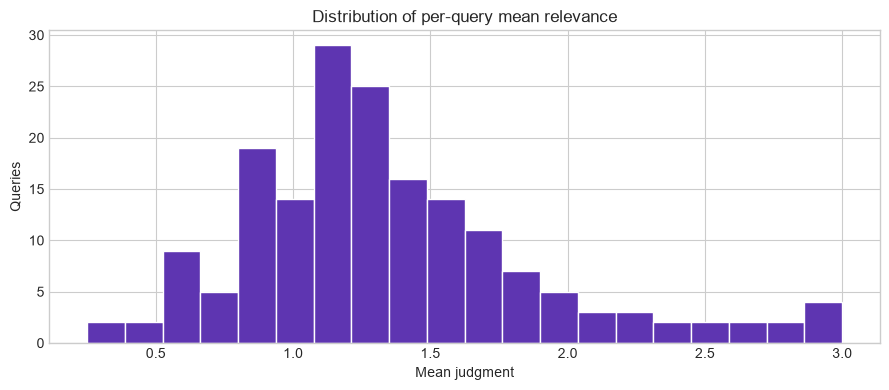

In [5]:
query_summary = (valid.groupby(['run_id', 'qid'], as_index=False)
    .agg(passages=('judgment', 'size'), mean_score=('judgment', 'mean'),
         relevant_at_2=('judgment', lambda s: int((s >= 2).sum())),
         exact=('judgment', lambda s: int((s == 3).sum())), query=('query', 'first')))
query_summary['relevant_at_2_rate'] = query_summary.relevant_at_2 / query_summary.passages
display(query_summary.sort_values(['relevant_at_2_rate', 'mean_score'], ascending=[False, False]))
ax = query_summary.mean_score.hist(bins=20, figsize=(9, 4), color='#5e35b1', edgecolor='white')
ax.set(title='Distribution of per-query mean relevance', xlabel='Mean judgment', ylabel='Queries')
plt.tight_layout(); plt.show()

## Passage inspector

Change the filters and rerun this cell to inspect individual judgments.

In [6]:
RUN = None       # e.g. 'aus-agent-dev-full'
QID = None       # paste an exact qid
SCORES = [2, 3]  # any subset of [0, 1, 2, 3]
LIMIT = 100

review = valid[valid.judgment.isin(SCORES)].copy()
if RUN: review = review[review.run_id.eq(RUN)]
if QID: review = review[review.qid.eq(QID)]
columns = [c for c in ['run_id', 'qid', 'docid', 'judgment', 'query', 'passage', 'prediction'] if c in review]
display(review[columns].head(LIMIT).reset_index(drop=True))

,run_id,qid,docid,judgment,query,passage,prediction
0,aus-agent-dev-full,aus-agent-dev-full::683a58c9a7e7fe4e7695846f,shard_06158_1343,2,"Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standar...",Spiral similarity is the mapping of the Euclidean plane given as a composition of homothety and rotation with a common center. This paper presents the basic...,##final score: 2
1,aus-agent-dev-full,aus-agent-dev-full::683a58c9a7e7fe4e7695846f,shard_02502_2629,3,"Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standar...","Mass point geometry\n\nMass point geometry, colloquially known as mass points, is a geometry problem-solving technique which applies the physical principle ...",##final score: 3
2,aus-agent-dev-full,aus-agent-dev-full::683a58c9a7e7fe4e7695846f,shard_02254_13801,2,"Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standar...","Geometry – All Theorems Collection\nGeometry problem solvers, here you can find theorems, exercises and interesting facts about our beloved Geometry.Wed, 21...",##final score: 2
3,aus-agent-test-full,aus-agent-test-full::rag2026-0,shard_00122_5199,2,I’m on a hospital nursing DEI council that has to recommend a three-year plan with limited money. Our chief nursing officer wants something that helps recru...,"The lack of diversity is a problem in nursing. Currently, 80% of registered nurses (RNs) identify as white, compared to 72% of the overall U.S. population, ...",##final score: 2
4,aus-agent-dev-full,aus-agent-dev-full::683a58c9a7e7fe4e7695846f,shard_00273_83656,2,"Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standar...",From time to time I am approached by students interested\nin advice about becoming more effective contestants\nin mathematics olympiads. Here it is.\nDo lot...,##final score: 2
...,...,...,...,...,...,...,...
95,aus-agent-test-full,aus-agent-test-full::rag2026-14,shard_03586_18014,2,"I help run a public library program for teens and adults, and people keep claiming that serious reading rewires empathy or that poetry is uniquely good for ...",Exposure to literature and the sorts of movies that do not involve car chases might nurture our capacity to get inside the skins of other people. Alternativ...,##final score: 2
96,aus-agent-test-full,aus-agent-test-full::rag2026-14,shard_01838_39712,2,"I help run a public library program for teens and adults, and people keep claiming that serious reading rewires empathy or that poetry is uniquely good for ...","Reading is a popular leisure activity for children, teenagers, and adults. Several theories agree that reading might improve social cognition, but the empir...",##final score: 2
97,aus-agent-test-full,aus-agent-test-full::rag2026-14,shard_02470_15021,2,"I help run a public library program for teens and adults, and people keep claiming that serious reading rewires empathy or that poetry is uniquely good for ...","In 2013, Science published a study with the intriguing title, “Reading Literary Fiction Improves Theory of Mind.” The authors (David Comer Kidd and Emanuele...",##final score: 2
98,aus-agent-test-full,aus-agent-test-full::rag2026-14,shard_02814_56030,2,"I help run a public library program for teens and adults, and people keep claiming that serious reading rewires empathy or that poetry is uniquely good for ...","Poetry is like music to the mind, scientists prove\n\nOctober 9, 2013\n\n(Medical Xpress)—New brain imaging technology is helping researchers to bridge the ...",##final score: 2


## Failed and suspicious rows

In [7]:
failed = df[df.status.ne('completed')].copy()
display(failed[[c for c in ['task_id', 'qid', 'docid', 'result_status', 'error'] if c in failed]].reset_index(drop=True))
if 'prediction' in df:
    suspicious = df[df.status.eq('completed') & ~df.prediction.fillna('').str.contains(r'##final score:\s*[0-3]', regex=True)]
    print(f'Completed rows without the expected score marker: {len(suspicious):,}')
    display(suspicious[[c for c in ['task_id', 'qid', 'docid', 'judgment', 'prediction'] if c in suspicious]].head(100))

,task_id,qid,docid,result_status,error
0,aus-agent-dev-full::683a58c9a7e7fe4e7695846f:4,aus-agent-dev-full::683a58c9a7e7fe4e7695846f,shard_03597_5856,failed,NaN
1,aus-agent-test-full::rag2026-22:5,aus-agent-test-full::rag2026-22,shard_03534_10840,failed,NaN
2,aus-agent-test-full::rag2026-39:5,aus-agent-test-full::rag2026-39,shard_05184_25060,failed,local agent completed without assistant text
3,aus-agent-test-v2::rag2026-5:8,aus-agent-test-v2::rag2026-5,shard_03335_58633,failed,local agent completed without assistant text
4,aus-agent-test-v2::rag2026-38:1,aus-agent-test-v2::rag2026-38,shard_02044_16728,failed,NaN
5,aus-agent-test-v2::rag2026-57:9,aus-agent-test-v2::rag2026-57,shard_05031_55869,failed,NaN
6,aus-agent-test-v2::rag2026-65:12,aus-agent-test-v2::rag2026-65,shard_04222_46386,failed,NaN
7,aus-agent-test-v2::rag2026-68:0,aus-agent-test-v2::rag2026-68,shard_06476_62518,failed,NaN
8,aus-agent-creative-check::683a58c9a7e7fe4e7695846f:10,aus-agent-creative-check::683a58c9a7e7fe4e7695846f,shard_03597_5856,failed,NaN


Completed rows without the expected score marker: 2


,task_id,qid,docid,judgment,prediction
139,aus-agent-dev-full::684397d188c1deceb49af31d:10,aus-agent-dev-full::684397d188c1deceb49af31d,shard_04181_19314,0,#final score: 0
191,aus-agent-dev-full::684397d188c1deceb49af32d:10,aus-agent-dev-full::684397d188c1deceb49af32d,shard_05103_7779,1,#final score: 1
